# Lab 2 — Digital Image Fundamentals
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers the lab manual:
1. **Sampling and Quantization**
2. **Arithmetic Operations** (add, subtract, add constant)
3. **Set / Logical Operations** (union, intersection, difference, symmetric difference)
4. **Practical Tasks**

> **Note on images:** The lab references `lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`. Since those files aren't bundled with the notebook, this notebook uses built-in `skimage` images so every cell runs out of the box. To use your own image, just replace the loading line.

## Setup

In [2]:
import cv2 # saves pics as arrays
import numpy as np
from PIL import Image # saves pics as regular images, franes? frages?
from skimage import data # it gives us the pics ready to go
import matplotlib.pyplot as plt # shows or displays the images

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).

In [11]:
def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2] # shaoe has height width and color channels (rgbs) 
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST) # resize to do downsampling
    return sampled_image # we downsized the image 
    # interpolation: ?

def quantize_image(image, levels): # for darkening the image 
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels) # 256: shades of grey
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

    # if its closer to 0 then we did the darkening correctly

def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

<Figure size 1600x400 with 0 Axes>

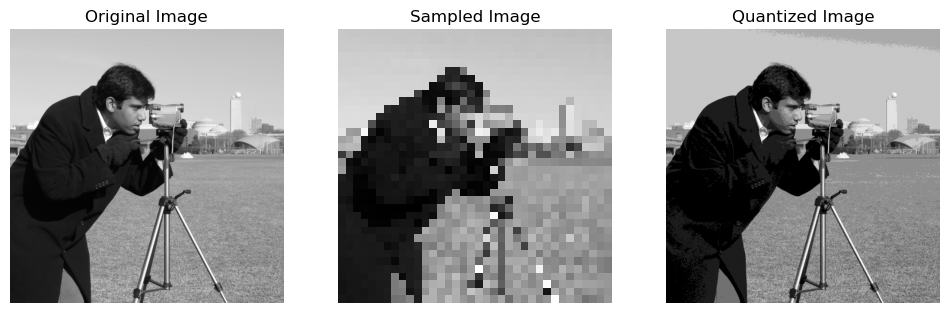

In [6]:
original_image = data.camera() # data has images allready we just need to call the function 

sampling_factor = 14
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

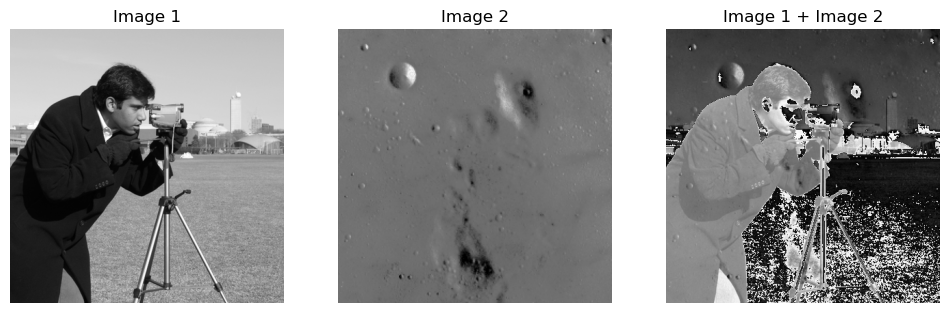

In [7]:
img1 = Image.fromarray(data.camera()) # we do these operations cause those images are considered as arrays
img2 = Image.fromarray(data.moon())

new_size = (400, 400) # the arrays OBVI have to be the same size to sum them
img1 = img1.resize(new_size, Image.Resampling.LANCZOS) # does calculations before choosing the nearest pixels, its better then internearest!
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
result_image = Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

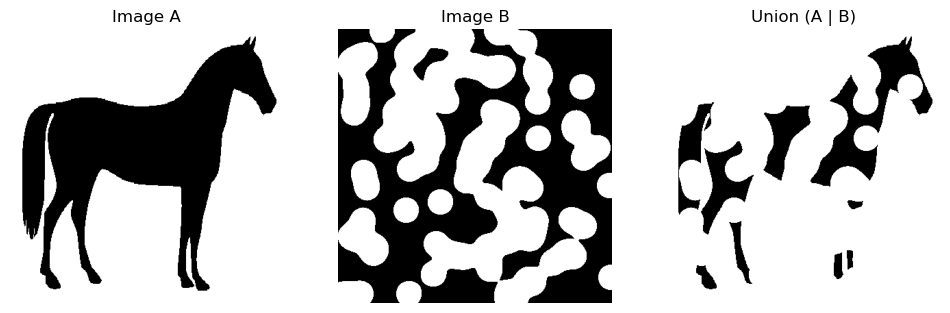

In [8]:
img3 = Image.fromarray(data.horse()) # downloaded the img, turn from array to img
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

### 1a) Effect of sampling factor (spatial resolution)

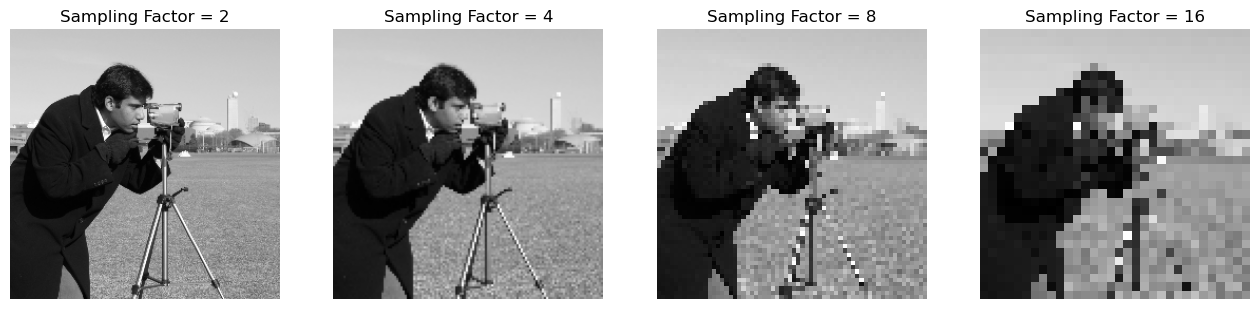

In [9]:
original_image = data.camera()

sampling_factors = [2, 4, 8, 16]

plt.figure(figsize=(16, 4))

for i, factor in enumerate(sampling_factors):
    sampled = sample_image(original_image, factor)

    plt.subplot(1, 4, i + 1)
    plt.imshow(sampled, cmap='gray')
    plt.title(f'Sampling Factor = {factor}')
    plt.axis('off')

plt.show()

### 1b) Effect of quantization levels (intensity resolution)

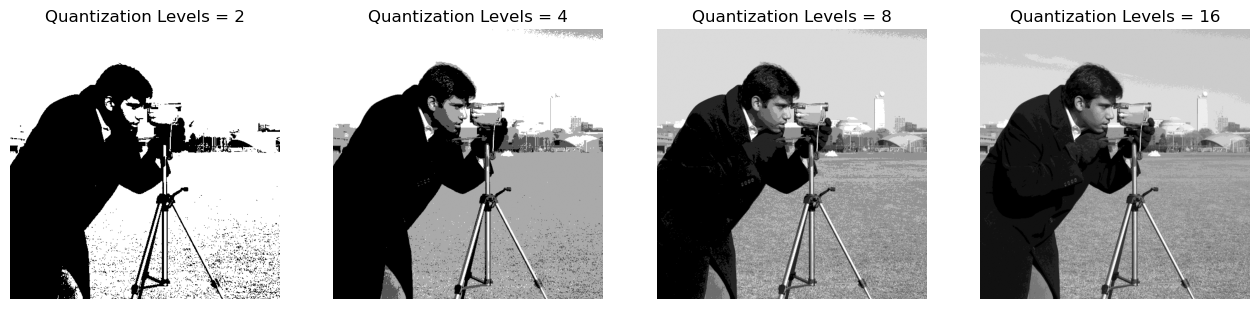

In [10]:
original_image = data.camera()

quantization_levels = [2, 4, 8, 16]

plt.figure(figsize=(16, 4))

for i, levels in enumerate(quantization_levels):
    quantized = quantize_image(original_image, levels)

    plt.subplot(1, 4, i + 1)
    plt.imshow(quantized, cmap='gray')
    plt.title(f'Quantization Levels = {levels}')
    plt.axis('off')

plt.show()

---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

### 2a) Subtract two images

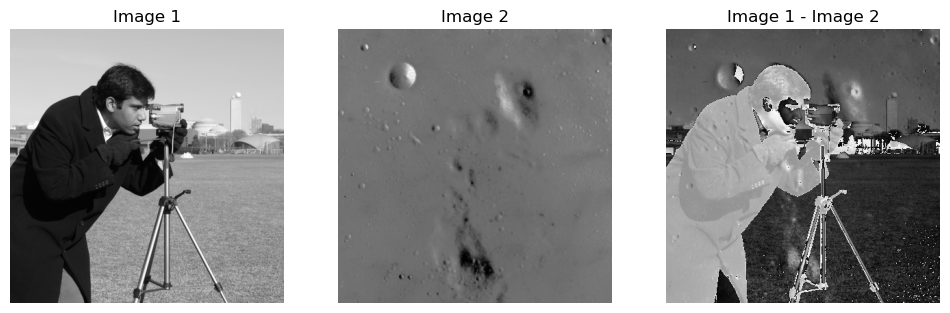

In [13]:
img1 = Image.fromarray(data.camera()) 
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

subtract = im1arr - im2arr
result_image = Image.fromarray(subtract)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 - Image 2'), plt.axis('off')
plt.show()

### 2b) Add image with constant value 175

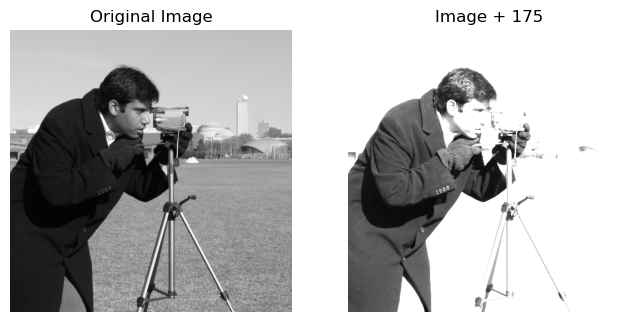

In [21]:
image = data.camera()

added_image = image.astype(np.int16) + 175 # 175 will make the image brighter since its closer to 255 

added_image = np.clip(added_image, 0, 255).astype(np.uint8) # this line is to make sure the number doesn't exceed 255 

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(added_image, cmap='gray')
plt.title('Image + 175')
plt.axis('off')

plt.show()

### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

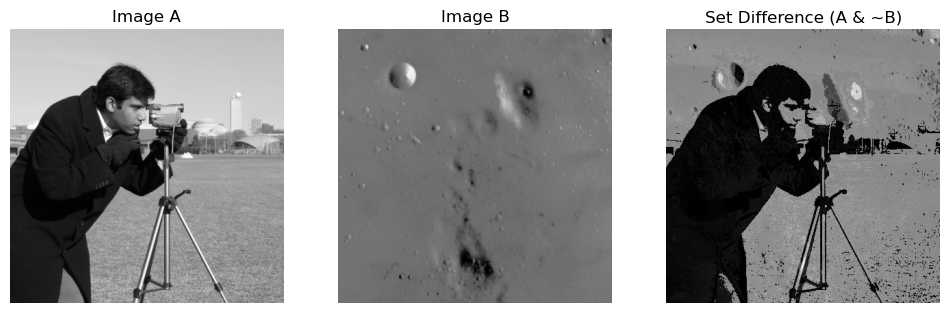

In [20]:
A = data.camera()
B = data.moon()

A = cv2.resize(A, (400, 400))
B = cv2.resize(B, (400, 400))

difference = A & (~B)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(A, cmap='gray')
plt.title('Image A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(B, cmap='gray')
plt.title('Image B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(difference, cmap='gray')
plt.title('Set Difference (A & ~B)')
plt.axis('off')

plt.show()

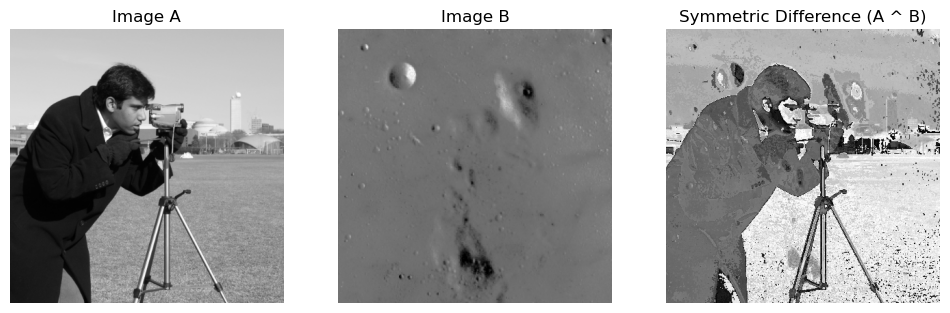

In [22]:
A = data.camera()
B = data.moon()

A = cv2.resize(A, (400, 400))
B = cv2.resize(B, (400, 400))

symmetric_difference = A ^ B

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(A, cmap='gray')
plt.title('Image A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(B, cmap='gray')
plt.title('Image B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(symmetric_difference, cmap='gray')
plt.title('Symmetric Difference (A ^ B)')
plt.axis('off')

plt.show()

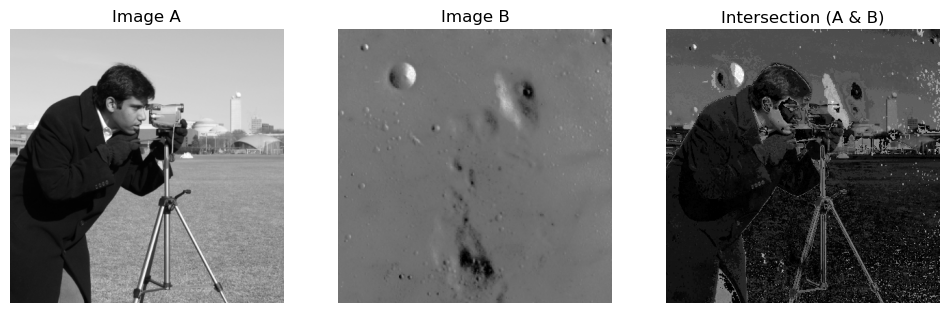

In [23]:
A = data.camera()
B = data.moon()

A = cv2.resize(A, (400, 400))
B = cv2.resize(B, (400, 400))

intersection = A & B

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(A, cmap='gray')
plt.title('Image A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(B, cmap='gray')
plt.title('Image B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(intersection, cmap='gray')
plt.title('Intersection (A & B)')
plt.axis('off')

plt.show()